<a href="https://colab.research.google.com/github/sujal003-hue/Upgrade-Capstone-Project/blob/main/Netflix_dataset_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob

# **Loading Our Dataset**

In [6]:
df = pd.read_csv('/content/netflix_titles.csv')

# **Display Top 5 Rows Of Our Dataset**

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **Display Last 5 Rows Of Our Dataset**

In [8]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


# **Check The Number Of Rows And Columns In Our Dataset**

In [9]:
df.shape

(8807, 12)

# **Check The Name Of Each And Every Columns Of Our Dataset**

In [20]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# **Statistical Measure Of Our Dataset**

In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# **Check The Null Values In Our Dataset**

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# **Removing The Duplicate Values In Our Dataset**

In [14]:
df_cleaned = df.dropna()
print("Shape of DataFrame after dropping nulls:", df_cleaned.shape)

# Verify that all null values have been removed
print("\nNull values after cleaning:")
display(df_cleaned.isnull().sum())

Shape of DataFrame after dropping nulls: (7290, 12)

Null values after cleaning:


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# **Exploratory Data Analysis**

In [13]:
df['director']= df['director'].fillna('Director not specified')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Directoe not specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Directoe not specified,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Directoe not specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
directors_list = pd.DataFrame()
print(directors_list)

Empty DataFrame
Columns: []
Index: []


In [21]:
directors_list = df['director'].str.split(',', expand=True).stack()
print(directors_list)

0     0           Kirsten Johnson
1     0    Directoe not specified
2     0           Julien Leclercq
3     0    Directoe not specified
4     0    Directoe not specified
                    ...          
8802  0             David Fincher
8803  0    Directoe not specified
8804  0           Ruben Fleischer
8805  0              Peter Hewitt
8806  0               Mozez Singh
Length: 9612, dtype: object


In [28]:
directors_list.columns = ['Director'] # Rename the column
print(directors_list)

                      Director
0    0         Kirsten Johnson
1    0  Directoe not specified
2    0         Julien Leclercq
3    0  Directoe not specified
4    0  Directoe not specified
...                        ...
8802 0           David Fincher
8803 0  Directoe not specified
8804 0         Ruben Fleischer
8805 0            Peter Hewitt
8806 0             Mozez Singh

[9612 rows x 1 columns]


In [30]:
directors = directors_list.groupby(['Director']).size().reset_index(name='Total Count')
print(directors)

                       Director  Total Count
0                Aaron Moorhead            2
1                   Aaron Woolf            1
2      Abbas Alibhai Burmawalla            1
3              Abdullah Al Noor            1
4           Abhinav Shiv Tiwari            1
...                         ...          ...
5116                Çagan Irmak            1
5117           Ísold Uggadóttir            1
5118        Óskar Thór Axelsson            1
5119           Ömer Faruk Sorak            2
5120               Şenol Sönmez            2

[5121 rows x 2 columns]


In [33]:
directors = directors[directors.Director != 'Directoe not specified']
print(directors)

                       Director  Total Count
0                Aaron Moorhead            2
1                   Aaron Woolf            1
2      Abbas Alibhai Burmawalla            1
3              Abdullah Al Noor            1
4           Abhinav Shiv Tiwari            1
...                         ...          ...
5116                Çagan Irmak            1
5117           Ísold Uggadóttir            1
5118        Óskar Thór Axelsson            1
5119           Ömer Faruk Sorak            2
5120               Şenol Sönmez            2

[5120 rows x 2 columns]


In [34]:
directors = directors.sort_values(['Total Count'], ascending=False)
print(directors)

                 Director  Total Count
4021        Rajiv Chilaka           22
4068          Raúl Campos           18
261             Jan Suter           18
3236         Marcus Raboy           16
4652          Suhas Kadav           16
...                   ...          ...
2331  Ivan Andrew Payawal            1
610    Songyos Sugmakanan            1
611          Sonia Dauger            1
612        Sophie Sartain            1
2336           Ivona Juka            1

[5120 rows x 2 columns]


In [35]:
top_5_directors = directors.head()
print(top_5_directors)

           Director  Total Count
4021  Rajiv Chilaka           22
4068    Raúl Campos           18
261       Jan Suter           18
3236   Marcus Raboy           16
4652    Suhas Kadav           16


# **Data Visualization Through Bar Chart**

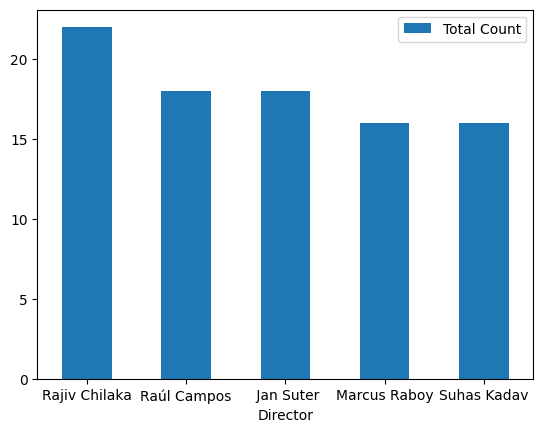

In [36]:
bar_chart = top_5_directors.plot.bar(x='Director', y='Total Count', rot=0)

In [11]:
x = df.groupby(['rating']).size().reset_index(name='counts')
print(x)

      rating  counts
0     66 min       1
1     74 min       1
2     84 min       1
3          G      41
4      NC-17       3
5         NR      80
6         PG     287
7      PG-13     490
8          R     799
9      TV-14    2160
10      TV-G     220
11     TV-MA    3207
12     TV-PG     863
13      TV-Y     307
14     TV-Y7     334
15  TV-Y7-FV       6
16        UR       3


# **Data Visualization Through Pie Chart**

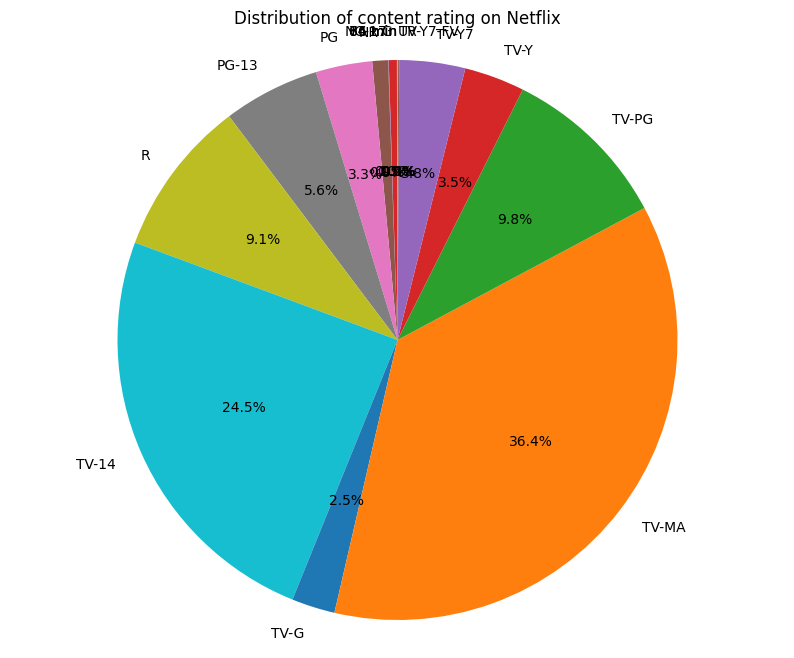

In [15]:
plt.figure(figsize=(10, 8))
plt.pie(x['counts'], labels=x['rating'], autopct='%1.1f%%', startangle=90)
plt.title("Distribution of content rating on Netflix")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# **Analyzing Top 5 Actors On Netflix**

# **Representing It Through Bar Chart**

                   Actor  counts
23624            Om Puri      27
15541      Julie Tejwani      28
30303   Takahiro Sakurai      30
26941       Rupa Bhimani      31
2612         Anupam Kher      39


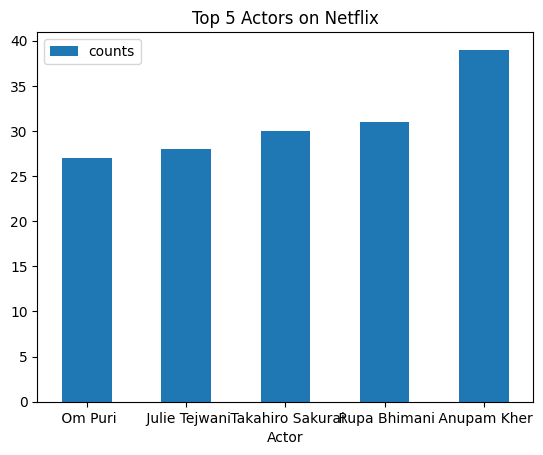

In [47]:
df['cast']= df['cast'].fillna('No cast specified')
cast_df = pd.DataFrame() # Reinitialize cast_df to ensure it's empty
cast_df = df['cast'].str.split(',',expand=True).stack()
cast_df = cast_df.to_frame()
cast_df.columns = ['Actor']
actor_counts = cast_df.groupby(['Actor']).size().reset_index(name='counts')
actors = actor_counts.sort_values(['counts'], ascending=False)

# Filter out 'No Cast Specified' before getting the top 5, stripping whitespace
actors_filtered = actors[actors['Actor'].str.strip() != 'No Cast Specified']
top_5_actors = actors_filtered.head(5)

top_5_actors = top_5_actors.sort_values(by=['counts']) # Corrected column name
print(top_5_actors)
barChart2 = top_5_actors.plot.bar(x='Actor', y='counts', rot=0, title = 'Top 5 Actors on Netflix')

# **Analyzing The Content Produced On Netflix Based On Years**

In [51]:
df1 = df[['type','release_year']]
df1 = df1.rename(columns = {"release_year":"Release Year","type": "Type"})
df2 = df1.groupby(["Release Year", "Type"]).size().reset_index(name="Total Count")

In [52]:
print(df2)

     Release Year     Type  Total Count
0            1925  TV Show            1
1            1942    Movie            2
2            1943    Movie            3
3            1944    Movie            3
4            1945    Movie            3
..            ...      ...          ...
114          2019  TV Show          397
115          2020    Movie          517
116          2020  TV Show          436
117          2021    Movie          277
118          2021  TV Show          315

[119 rows x 3 columns]


# **Data Visualization Through Line Chart**

In [53]:
graph = px.line(df2, x = "Release Year", y="Total Count", color="Type", title="Trend of Content Produced on Netflix Every Year")
graph.show()

# **Sentiment Analysis Of Netflix Content**

In [55]:
df3 = df[["release_year", "description"]]
df3 = df3.rename(columns={"release_year": "Release Year", "description": "Description"})

sentiments = []
for index, row in df3.iterrows():
    d = str(row['Description'])
    testimonial = TextBlob(d)
    p = testimonial.sentiment.polarity
    if p == 0:
        sent = "Neutral"
    elif p > 0:
        sent = "Positive"
    else:
        sent = "Negative"
    sentiments.append(sent)

df3['Sentiment'] = sentiments

df3_grouped = df3.groupby(['Release Year', 'Sentiment']).size().reset_index(name='Total Count')
df3_filtered = df3_grouped[df3_grouped['Release Year'] >= 2005] # Assuming filter for years >= 2005

bargraph = px.bar(df3_filtered, x="Release Year", y="Total Count", color="Sentiment", title="Sentiment Analysis of Content on Netflix")
bargraph.show()

# **Conclusion**

**To conclude by saying that we perform data analysis on above dataset. Firstly, we load our dataset, perform Exploratory Data Analysis(EDA), check the number of rows and columns and name of each column. We also check the null values and remove the duplicate values and statistical measure of the dataset. We also perform data visualization in form of bar chart, pie chart as well as line chart. At last, we also do sentiment analysis of the above dataset.**